In [1]:
!pip install plotly

In [2]:
import plotly.express as px
import pandas as pd

In [3]:
#line chart

In [4]:
import requests
import pandas as pd
import pprint

url = "https://storage.dosm.gov.my/population/population_malaysia.csv"
df = pd.read_csv(url)

In [5]:
df

,date,sex,age,ethnicity,population
0,1970-01-01,both,overall,overall,10881.8
1,1970-01-01,both,0-4,overall,1702.4
2,1970-01-01,both,5-9,overall,1690.3
3,1970-01-01,both,10-14,overall,1454.7
4,1970-01-01,both,15-19,overall,1197.6
...,...,...,...,...,...
17410,2025-01-01,male,85+,bumi_other,11.1
17411,2025-01-01,male,85+,chinese,14.8
17412,2025-01-01,male,85+,indian,4.8
17413,2025-01-01,male,85+,other_citizen,0.6


In [6]:
df["date"]=pd.to_datetime(df["date"])
df["year"]=df["date"].dt.year

In [7]:
df_year = df.groupby("year").agg(Total_Population = ("population","sum")).reset_index()
px.line(df_year,x="year",y="Total_Population",markers=True)

In [8]:
import plotly.express as px

df_year_sex = (
    df.groupby(["year", "sex"])
      .agg(Total_Population=("population", "sum"))
      .reset_index()
)

df_year_sex


,year,sex,Total_Population
0,1970,both,21763.6
1,1970,female,10729.4
2,1970,male,11034.1
3,1971,both,22319.3
4,1971,female,11012.9
...,...,...,...
163,2024,female,64692.6
164,2024,male,71516.6
165,2025,both,136926.8
166,2025,female,65095.6


In [9]:
fig = px.line(
    df_year_sex,
    x="year",
    y="Total_Population",
    color="sex",          # 👈 THIS creates gender split
    markers=True,
    title="Year-wise Population Trend by Gender"
)

fig.show()

In [10]:
import plotly.express as px

df_3d = (
    df.groupby(["year", "sex"])
      .agg(Total_Population=("population", "sum"))
      .reset_index()
)

In [11]:
fig = px.line_3d(
    df_3d,
    x="year",
    y="sex",
    z="Total_Population",
    color="sex",
    #markers=True,
    title="3D Population Trend by Gender"
)

fig.show()

In [12]:
# Import required libraries
import pandas as pd
import plotly.express as px

# 1. Aggregate population by year and gender
df_anim = (
    df.groupby(["year", "sex"])              # Group data by year and gender
      .agg(Total_Population=("population", "sum"))  # Sum population
      .reset_index()                          # Convert groupby output to DataFrame
)

# 2. Create cumulative data for animation (to make line grow over time)
frames = []                                   # List to store animation frames

for y in sorted(df_anim["year"].unique()):    # Loop through years in order
    temp = df_anim[df_anim["year"] <= y].copy()  # Take data up to current year
    temp["frame_year"] = y                    # Add animation frame column
    frames.append(temp)                       # Store frame

# Combine all frames into a single DataFrame
df_cum = pd.concat(frames)

# 3. Create animated cumulative line chart
fig = px.line(
    df_cum,
    x="year",                                 # X-axis = year
    y="Total_Population",                     # Y-axis = population
    color="sex",                              # Separate line by gender
    markers=True,                             # Show markers on line
    animation_frame="frame_year",             # Animate by year
    animation_group="sex",                    # Keep gender lines connected
    title="Cumulative Animated Population Trend by Gender"
)

# 4. Lock X and Y axes to avoid chart jumping during animation
fig.update_layout(
    xaxis=dict(
        range=[df_cum["year"].min(), df_cum["year"].max()],
        fixedrange=True
    ),
    yaxis=dict(
        range=[0, df_cum["Total_Population"].max() * 1.1],
        fixedrange=True
    )
)

# 5. Control animation speed (milliseconds)
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 500
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 300

# 6. Display the animated chart
fig.show()

In [13]:
# -------------------------------------------------------
# GOAL:
# Make the line "grow" year by year in animation.
# Plotly does NOT remember old points automatically,
# so we manually repeat past data for each new frame.
# -------------------------------------------------------

# Example df_anim looks like this:
# year   sex     Total_Population
# 2018   male    100
# 2018   female  95
# 2019   male    110
# 2019   female  105
# 2020   male    120
# 2020   female  115

frames = []  # This list will store data for each animation step (frame)

# Loop through each year in ascending order
for i in sorted(df_anim["year"].unique()):

    # Select ALL rows from the beginning up to the current year
    # This is what makes the line extend instead of resetting
    temp = df_anim[df_anim["year"] <= i].copy()

    # Add a column that tells Plotly:
    # "Show this data when the animation is at year = y"
    temp["frame_year"] = i

    # Save this cumulative snapshot into the frames list
    frames.append(temp)

# Combine all yearly snapshots into ONE DataFrame
# Rows are intentionally repeated — this is required for animation
df_cum = pd.concat(frames)

# After this:
# - frame_year = 2018 → only 2018 points shown
# - frame_year = 2019 → 2018 + 2019 points shown
# - frame_year = 2020 → 2018 + 2019 + 2020 points shown
# Result: line grows smoothly over time

In [14]:
df_cum

,year,sex,Total_Population,frame_year
0,1970,both,21763.6,1970
1,1970,female,10729.4,1970
2,1970,male,11034.1,1970
0,1970,both,21763.6,1971
1,1970,female,10729.4,1971
...,...,...,...,...
163,2024,female,64692.6,2025
164,2024,male,71516.6,2025
165,2025,both,136926.8,2025
166,2025,female,65095.6,2025


In [15]:
frames

[   year     sex  Total_Population  frame_year
 0  1970    both           21763.6        1970
 1  1970  female           10729.4        1970
 2  1970    male           11034.1        1970,
    year     sex  Total_Population  frame_year
 0  1970    both           21763.6        1971
 1  1970  female           10729.4        1971
 2  1970    male           11034.1        1971
 3  1971    both           22319.3        1971
 4  1971  female           11012.9        1971
 5  1971    male           11306.7        1971,
    year     sex  Total_Population  frame_year
 0  1970    both           21763.6        1972
 1  1970  female           10729.4        1972
 2  1970    male           11034.1        1972
 3  1971    both           22319.3        1972
 4  1971  female           11012.9        1972
 5  1971    male           11306.7        1972
 6  1972    both           22882.5        1972
 7  1972  female           11299.6        1972
 8  1972    male           11582.9        1972,
     year 

In [16]:
df_cum[df_cum["frame_year"]==1980]

,year,sex,Total_Population,frame_year
0,1970,both,21763.6,1980
1,1970,female,10729.4,1980
2,1970,male,11034.1,1980
3,1971,both,22319.3,1980
4,1971,female,11012.9,1980
5,1971,male,11306.7,1980
6,1972,both,22882.5,1980
7,1972,female,11299.6,1980
8,1972,male,11582.9,1980
9,1973,both,23439.5,1980


In [17]:
# Import required libraries
import pandas as pd
import plotly.express as px

# 1. Aggregate population by year and gender
df_anim = (
    df.groupby(["year", "sex"])              # Group data by year and gender
      .agg(Total_Population=("population", "sum"))  # Sum population
      .reset_index()                          # Convert groupby output to DataFrame
)

# 2. Create normal animated line chart (NON-CUMULATIVE)
fig = px.line(
    df_anim,
    x="year",                                 # X-axis = year
    y="Total_Population",                     # Y-axis = population
    color="sex",                              # Separate line by gender
    markers=True,                             # Show markers
    animation_frame="year",                   # Animate by year
    animation_group="sex",                    # Keep gender identity per frame
    title="Animated Population Trend by Gender (Non-Cumulative)"
)

# 3. Lock axes so chart does not jump
fig.update_layout(
    xaxis=dict(
        range=[df_anim["year"].min(), df_anim["year"].max()],
        fixedrange=True
    ),
    yaxis=dict(
        range=[0, df_anim["Total_Population"].max() * 1.1],
        fixedrange=True
    )
)

# 4. Control animation speed
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 1000

# 5. Display the animated chart
fig.show()

In [18]:
import plotly.express as px

# Aggregate population by year
df_bar = (
    df.groupby("year")
      .agg(Total_Population=("population", "sum"))
      .reset_index()
)

# Create bar chart
fig = px.bar(
    df_bar,
    x="year",
    y="Total_Population",
    title="Year-wise Total Population",
    text_auto=True
)

fig.show()

In [19]:
df_bar_gender = (
    df.groupby(["year", "sex"])
      .agg(Total_Population=("population", "sum"))
      .reset_index()
)

fig = px.bar(
    df_bar_gender,
    x="year",
    y="Total_Population",
    color="sex",
    barmode="group",
    title="Year-wise Population by Gender",
    text_auto=True
)

fig.show()

In [20]:
fig = px.bar(
    df_bar_gender,
    x="year",
    y="Total_Population",
    color="sex",
    barmode="stack",
    title="Year-wise Population (Stacked by Gender)"
)

fig.show()

WHich etnicity having higher population


In [21]:
#remove the over all
#in 2025 Top ethnicity population split

In [22]:
df.columns

Index(['date', 'sex', 'age', 'ethnicity', 'population', 'year'], dtype='object')

In [23]:
df.drop(df[df["ethnicity"]=="overall"].index,axis="rows",inplace=True)

In [24]:
df["ethnicity"].unique()

array(['bumi', 'chinese', 'indian', 'other', 'bumi_malay', 'bumi_other',
       'other_citizen', 'other_noncitizen'], dtype=object)

In [25]:
df_bar = (
    df.groupby(["ethnicity","sex"])
      .agg(Total_Population=("population", "sum"))
      .reset_index()
)

# Create bar chart
fig = px.bar(
    df_bar,
    x="ethnicity",
    y="Total_Population",
    color ="sex",
    barmode="group",
    title="Ethnicity-wise Total Population",
    text_auto=True
)

fig.show()

In [26]:
import pandas as pd
#export?format=csv
url="https://docs.google.com/spreadsheets/d/1RVnUAGVsr4lrt7nZ2WOq2hFkj7gFcRef/export?format=csv"
df=pd.read_csv(url)

In [27]:
df.select_dtypes(include=["int","float"]).corr()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


<Axes: >

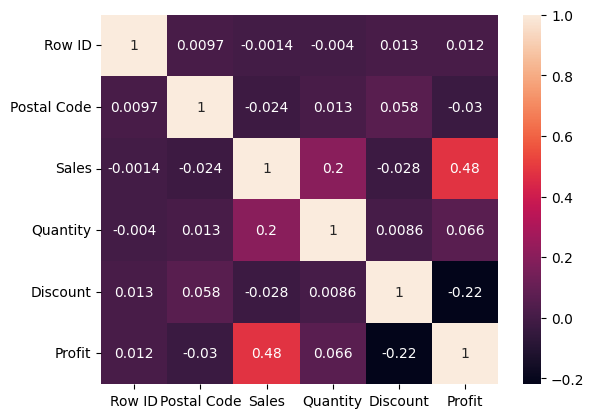

In [28]:
import seaborn as sns
sns.heatmap(df.select_dtypes(include=["int","float"]).corr(),annot=True)

In [29]:
df1=df[df["Segment"]=="Consumer"]
df1.to_csv("result.csv")
df1.to_excel("result.xlsx")

In [30]:
import seaborn as sns
df = sns.load_dataset("tips")
df[df["day"].isin(["Sun","Mon"])]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3
187,30.46,2.00,Male,Yes,Sun,Dinner,5
188,18.15,3.50,Female,Yes,Sun,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3
